 #Clustering for Patient Segmentation

This notebook rebuilds the original analysis in a simpler, more teachable way.

The goal is not only to **run the code**, but to understand:

- what each code chunk does,
- why we are using it,
- and the reusable **code pattern** behind it.

We will use the patient dataset to group similar patients into clusters using **K-means clustering**.

## What is in this dataset?

The dataset contains 6,000 patient records and 16 columns, including:

- demographic information such as age and residence type,
- clinical measurements such as blood pressure, cholesterol, glucose, insulin, and BMI,
- health history indicators such as hypertension and heart disease,
- lifestyle information such as smoking status.

Because clustering is an **unsupervised learning** task, we are not trying to predict a target.  
Instead, we are trying to discover natural patient groups hidden inside the data.

## Step 0: Install packages

**What this code does:**  
This cell installs the Python libraries used in the notebook.

**Why this matters:**  
A notebook can only use packages that are already installed. In many hosted notebook environments, these packages are already available, so this cell may not be necessary. It is included for completeness.

In [ ]:
# In many notebook environments, these libraries are already installed.
# If your environment already has them, you can skip this cell.
!pip -q install pandas numpy matplotlib seaborn scikit-learn

**Code pattern to learn:**  
When a project depends on external libraries, install them first.

**General pattern:**
```python
!pip install package_name
```

Use this pattern when you open a fresh notebook environment and need required tools.

## Step 1: Import the libraries

**What this code does:**  
This cell imports the libraries used for data loading, cleaning, visualization, preprocessing, and clustering.

**Why this matters:**  
Most data projects begin by importing the tools you will need. Each library has a specific job.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Matplotlib is building the font cache; this may take a moment.


**Code pattern to learn:**  
Data science notebooks usually import libraries at the top.

**General pattern:**
```python
import library_name as short_name
from package.subpackage import ToolName
```

You do this once, then reuse those tools throughout the notebook.

## Step 2: Load the dataset

**What this code does:**  
This cell reads the CSV file into a pandas DataFrame called `df`.

**Why this matters:**  
A DataFrame is the main table structure used in pandas. Once the data is loaded, we can inspect, clean, transform, and analyze it.

In [ ]:
file_path = "/content/patient_dataset.csv"
df = pd.read_csv(file_path)

df.head()

,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,residence_type,smoking_status
0,24,1.0,4,250,139,212,0,108.0,33.0,109.0,37.999303,0.480277,1,1,Urban,Smoker
1,29,0.0,4,132,187,147,0,202.0,42.0,NaN,25.588346,0.283986,1,1,Urban,Unknown
2,46,0.0,3,271,185,193,0,149.0,43.0,102.0,37.892029,2.472309,1,0,Rural,Non-Smoker
3,73,NaN,2,102,200,125,0,105.0,77.0,165.0,18.660241,1.472052,0,1,Rural,Smoker
4,49,1.0,3,91,163,192,0,162.0,31.0,170.0,12.767980,0.537627,1,1,Rural,Smoker


**Code pattern to learn:**  
Load a CSV into a DataFrame, then preview the first few rows.

**General pattern:**
```python
df = pd.read_csv("path/to/file.csv")
df.head()
```

This is one of the most common starting patterns in data analysis.

## Step 3: Check the size and columns

**What this code does:**  
This cell shows how many rows and columns the dataset has, and lists the column names.

**Why this matters:**  
Before analyzing data, you should know what fields exist and how large the dataset is.

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (6000, 16)

Column names:
['age', 'gender', 'chest_pain_type', 'blood_pressure', 'cholesterol', 'max_heart_rate', 'exercise_angina', 'plasma_glucose', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease', 'residence_type', 'smoking_status']


**Code pattern to learn:**  
Use `.shape` to see the table size and `.columns` to inspect the field names.

**General pattern:**
```python
print(df.shape)
print(df.columns.tolist())
```

This helps you quickly orient yourself in a new dataset.

## Step 4: Inspect data types and missing values

**What this code does:**  
This cell checks:
1. each column's data type,
2. how many non-missing values each column has,
3. how many missing values exist in every column.

**Why this matters:**  
Clustering algorithms cannot handle raw missing values. We need to find them before preprocessing.

In [ ]:
print("DataFrame info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                6000 non-null   int64  
 1   gender             5528 non-null   float64
 2   chest_pain_type    6000 non-null   int64  
 3   blood_pressure     6000 non-null   int64  
 4   cholesterol        6000 non-null   int64  
 5   max_heart_rate     6000 non-null   int64  
 6   exercise_angina    6000 non-null   int64  
 7   plasma_glucose     5391 non-null   float64
 8   skin_thickness     5386 non-null   float64
 9   insulin            5432 non-null   float64
 10  bmi                6000 non-null   float64
 11  diabetes_pedigree  6000 non-null   float64
 12  hypertension       6000 non-null   int64  
 13  heart_disease      6000 non-null   int64  
 14  residence_type     5545 non-null   object 
 15  smoking_status     6000 non-null   object 
dtypes: float

**Code pattern to learn:**  
Use `.info()` for structure and `.isnull().sum()` for missing-value counts.

**General pattern:**
```python
df.info()
df.isnull().sum()
```

This pattern is part of basic data quality checking.

## Step 5: Separate numeric and categorical columns

**What this code does:**  
This cell creates two lists:
- `numeric_cols` for numeric variables,
- `categorical_cols` for text/category variables.

**Why this matters:**  
Different kinds of columns need different preprocessing steps.  
For example:
- numeric columns are usually scaled,
- categorical columns are usually encoded.

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['age', 'gender', 'chest_pain_type', 'blood_pressure', 'cholesterol', 'max_heart_rate', 'exercise_angina', 'plasma_glucose', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease']

Categorical columns:
['residence_type', 'smoking_status']


**Code pattern to learn:**  
Use `select_dtypes()` when you want to process columns by type.

**General pattern:**
```python
numeric_cols = df.select_dtypes(include=[...]).columns.tolist()
categorical_cols = df.select_dtypes(include=[...]).columns.tolist()
```

This lets you build workflows that adapt to the structure of the dataset.

## Step 6: Summarize the data

**What this code does:**  
This cell gives:
- summary statistics for numeric columns,
- unique values for categorical columns.

**Why this matters:**  
This helps you understand value ranges, distributions, and category names before cleaning the data.

In [ ]:
print("Summary statistics for numeric columns:")
display(df[numeric_cols].describe())

print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}: {df[col].dropna().unique()}")

Summary statistics for numeric columns:


,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease
count,6000.000000,5528.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,5391.000000,5386.000000,5432.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,53.657833,0.497648,2.518500,134.277167,209.844667,144.996000,0.503167,161.119644,59.964723,129.601252,29.941495,1.294623,0.501333,0.498167
std,21.018382,0.500040,1.124071,48.303001,52.840432,43.583318,0.500032,52.434693,23.264030,29.207479,11.626425,0.689932,0.500040,0.500038
min,18.000000,0.000000,1.000000,0.000000,120.000000,70.000000,0.000000,70.000000,20.000000,80.000000,10.006670,0.100068,0.000000,0.000000
25%,36.000000,0.000000,2.000000,109.000000,164.000000,108.000000,0.000000,116.000000,40.000000,105.000000,19.797401,0.690522,0.000000,0.000000
50%,53.000000,0.000000,3.000000,135.000000,210.000000,144.000000,1.000000,162.000000,60.000000,129.000000,29.940303,1.294057,1.000000,0.000000
75%,72.000000,1.000000,4.000000,161.000000,257.000000,183.000000,1.000000,206.000000,80.000000,155.000000,39.859571,1.899079,1.000000,1.000000
max,90.000000,1.000000,4.000000,300.000000,300.000000,220.000000,1.000000,250.000000,100.000000,180.000000,49.999449,2.499635,1.000000,1.000000



Unique values in categorical columns:

residence_type: ['Urban' 'Rural']

smoking_status: ['Smoker' 'Unknown' 'Non-Smoker']


**Code pattern to learn:**  
Use `.describe()` for numeric summaries and `.unique()` for category inspection.

**General pattern:**
```python
df[numeric_cols].describe()

for col in categorical_cols:
    print(df[col].unique())
```

This pattern helps you understand the contents of each feature before modeling.

## Step 7: Fill missing values

**What this code does:**  
This cell fills missing values:
- numeric columns get the **mean**,
- categorical columns get the **mode** (most common value).

**Why this matters:**  
K-means cannot work with missing values, so we must replace them before clustering.

In [ ]:
df_clean = df.copy()

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after filling:")
print(df_clean.isnull().sum())

Missing values after filling:
age                  0
gender               0
chest_pain_type      0
blood_pressure       0
cholesterol          0
max_heart_rate       0
exercise_angina      0
plasma_glucose       0
skin_thickness       0
insulin              0
bmi                  0
diabetes_pedigree    0
hypertension         0
heart_disease        0
residence_type       0
smoking_status       0
dtype: int64


**Code pattern to learn:**  
A common beginner-friendly approach is:
- use the mean for numeric missing values,
- use the mode for categorical missing values.

**General pattern:**
```python
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
```

This is a simple baseline cleaning pattern for many tabular datasets.

## Step 8: Encode categorical variables

**What this code does:**  
This cell converts categorical text columns into numeric columns using **one-hot encoding**.

**Why this matters:**  
K-means works with numbers, not raw text labels.  
For example, a category like `Urban` / `Rural` must be turned into numeric indicator columns.

In [ ]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.head()

Encoded dataset shape: (6000, 17)


,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,residence_type_Urban,smoking_status_Smoker,smoking_status_Unknown
0,24,1.000000,4,250,139,212,0,108.0,33.0,109.000000,37.999303,0.480277,1,1,True,True,False
1,29,0.000000,4,132,187,147,0,202.0,42.0,129.601252,25.588346,0.283986,1,1,True,False,True
2,46,0.000000,3,271,185,193,0,149.0,43.0,102.000000,37.892029,2.472309,1,0,False,False,False
3,73,0.497648,2,102,200,125,0,105.0,77.0,165.000000,18.660241,1.472052,0,1,False,True,False
4,49,1.000000,3,91,163,192,0,162.0,31.0,170.000000,12.767980,0.537627,1,1,False,True,False


**Code pattern to learn:**  
Use `pd.get_dummies()` to turn categories into binary columns.

**General pattern:**
```python
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
```

This is a standard pattern when machine learning models need numeric input.

## Step 9: Standardize the features

**What this code does:**  
This cell scales all features so that they are on a comparable scale.

**Why this matters:**  
K-means uses distance. If one feature has much larger values than another, it can dominate the clustering.  
Standardization solves that by putting features on a similar scale.

In [ ]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(scaled_array, columns=df_encoded.columns)

df_scaled.head()

,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,residence_type_Urban,smoking_status_Smoker,smoking_status_Unknown
0,-1.411160,1.046729,1.318087,2.395969,-1.340840,1.537505,-1.006354,-1.068852,-1.223471,-0.741370,0.693118,-1.180427,0.997337,1.003673,0.925128,1.074069,-0.293546
1,-1.173253,-1.036929,1.318087,-0.047147,-0.432369,0.045985,-1.006354,0.822578,-0.815114,0.000000,-0.374450,-1.464958,0.997337,1.003673,0.925128,-0.931038,3.406617
2,-0.364370,-1.036929,0.428390,2.830761,-0.470222,1.101522,-1.006354,-0.243867,-0.769741,-0.993277,0.683890,1.707102,0.997337,-0.996340,-1.080932,-0.931038,-0.293546
3,0.920327,0.000000,-0.461308,-0.668278,-0.186325,-0.458838,-1.006354,-1.129217,0.772942,1.273883,-0.970392,0.257191,-1.002670,1.003673,-1.080932,1.074069,-0.293546
4,-0.221626,1.046729,0.428390,-0.896027,-0.886605,1.078576,-1.006354,0.017714,-1.314217,1.453816,-1.477234,-1.097297,0.997337,1.003673,-1.080932,1.074069,-0.293546


**Code pattern to learn:**  
For distance-based algorithms, scaling is usually essential.

**General pattern:**
```python
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(scaled_array, columns=df_features.columns)
```

Fit the scaler on the data, transform it, then convert the result back into a DataFrame for readability.

## Step 10: Build the K-means model

**What this code does:**  
This cell creates and fits a K-means model with `k = 3`.

**Why this matters:**  
K-means tries to split the data into a chosen number of clusters.  
Here, `3` is used as a simple demonstration choice, matching the original notebook.

In [ ]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(df_scaled)
cluster_labels = kmeans.labels_

print("Clustering complete.")
print("First 10 cluster labels:", cluster_labels[:10])

Clustering complete.
First 10 cluster labels: [1 0 2 1 1 2 2 1 2 2]


**Code pattern to learn:**  
Most scikit-learn models follow the same workflow:
1. create the model,
2. fit the model,
3. read results.

**General pattern:**
```python
model = ModelName(parameters...)
model.fit(X)
results = model.some_attribute_
```

This pattern appears in clustering, classification, regression, and dimensionality reduction.

## Step 11: Attach cluster labels to the data

**What this code does:**  
This cell adds the cluster result to both:
- the scaled dataset,
- the cleaned original dataset.

**Why this matters:**  
Once each row has a cluster label, we can compare clusters and understand what each group looks like.

In [ ]:
df_scaled["Cluster"] = cluster_labels
df_result = df_clean.copy()
df_result["Cluster"] = cluster_labels

print(df_result["Cluster"].value_counts().sort_index())
df_result.head()

Cluster
0     476
1    2786
2    2738
Name: count, dtype: int64


,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,residence_type,smoking_status,Cluster
0,24,1.000000,4,250,139,212,0,108.0,33.0,109.000000,37.999303,0.480277,1,1,Urban,Smoker,1
1,29,0.000000,4,132,187,147,0,202.0,42.0,129.601252,25.588346,0.283986,1,1,Urban,Unknown,0
2,46,0.000000,3,271,185,193,0,149.0,43.0,102.000000,37.892029,2.472309,1,0,Rural,Non-Smoker,2
3,73,0.497648,2,102,200,125,0,105.0,77.0,165.000000,18.660241,1.472052,0,1,Rural,Smoker,1
4,49,1.000000,3,91,163,192,0,162.0,31.0,170.000000,12.767980,0.537627,1,1,Rural,Smoker,1


**Code pattern to learn:**  
After modeling, it is common to add the result back to the original rows.

**General pattern:**
```python
df["NewLabel"] = result_array
```

This makes it easier to summarize and interpret results row by row.

## Step 12: Examine average feature values by cluster

**What this code does:**  
This cell calculates the mean of each numeric feature inside each cluster.

**Why this matters:**  
This is one of the best ways to interpret clusters.  
It helps answer questions like:
- Which cluster has older patients?
- Which cluster has higher glucose?
- Which cluster has higher BMI or cholesterol?

In [ ]:
cluster_profile = df_result.groupby("Cluster").mean(numeric_only=True)
display(cluster_profile)

,age,gender,chest_pain_type,blood_pressure,cholesterol,max_heart_rate,exercise_angina,plasma_glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease
Cluster,,,,,,,,,,,,,,
0,53.936975,0.476703,2.514706,131.798319,207.636555,145.415966,0.529412,164.386266,59.250126,128.644651,29.610166,1.288891,0.476891,0.523109
1,53.600144,0.499642,2.531587,134.670854,209.730438,144.416009,0.497846,160.668408,60.392249,129.677789,29.778856,1.297349,0.506461,0.502154
2,53.668006,0.499261,2.505844,134.307524,210.344777,145.513148,0.504018,161.010890,59.653935,129.689678,30.164585,1.292846,0.500365,0.489774


**Code pattern to learn:**  
Grouping by a label and then taking summary statistics is a core analysis pattern.

**General pattern:**
```python
df.groupby("GroupColumn").mean(numeric_only=True)
```

You can replace `.mean()` with `.median()`, `.sum()`, `.count()`, and more depending on your question.

## Step 13: Check cluster sizes

**What this code does:**  
This cell counts how many patients fall into each cluster.

**Why this matters:**  
Cluster size tells you whether the groups are balanced or whether one cluster is much larger than the others.

In [ ]:
cluster_sizes = df_result["Cluster"].value_counts().sort_index()
print(cluster_sizes)

Cluster
0     476
1    2786
2    2738
Name: count, dtype: int64


**Code pattern to learn:**  
Use `.value_counts()` to count how many times each label appears.

**General pattern:**
```python
df["label_column"].value_counts()
```

This pattern is useful for clusters, classes, categories, and flags.

## Step 14: Visualize cluster profiles with a heatmap

**What this code does:**  
This cell creates a heatmap of the average numeric values in each cluster.

**Why this matters:**  
Tables are useful, but visuals make patterns easier to spot quickly.

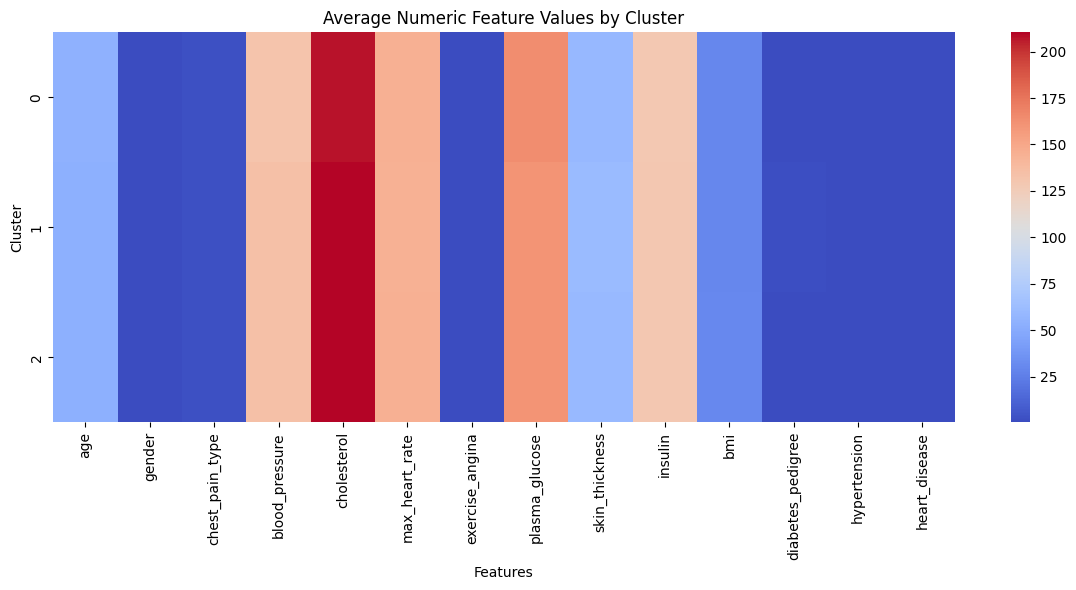

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile, cmap="coolwarm", annot=False)
plt.title("Average Numeric Feature Values by Cluster")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

**Code pattern to learn:**  
Heatmaps are useful when you want to compare many variables across groups.

**General pattern:**
```python
sns.heatmap(table_data, cmap="...")
plt.show()
```

Use a heatmap when the data is already in matrix or summary-table form.

## Step 15: Reduce the data to 2 dimensions with PCA

**What this code does:**  
This cell uses **Principal Component Analysis (PCA)** to reduce the scaled feature space to 2 dimensions.

**Why this matters:**  
The real dataset has many features, which are hard to visualize directly.  
PCA gives us a 2D view that helps us see how clusters are separated.

In [ ]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled.drop(columns=["Cluster"]))

df_pca = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
df_pca["Cluster"] = cluster_labels

df_pca.head()

,PC1,PC2,Cluster
0,-1.129716,2.387937,1
1,3.067631,0.183260,0
2,0.309147,1.746800,2
3,-1.068921,-0.930744,1
4,-0.922705,1.550261,1


**Code pattern to learn:**  
Dimensionality reduction often follows this pattern:
1. create the reducer,
2. fit and transform the feature matrix,
3. store the reduced output in a new DataFrame.

**General pattern:**
```python
reducer = PCA(n_components=2)
X_reduced = reducer.fit_transform(X)
```

This pattern is common for visualization before plotting.

## Step 16: Plot the clusters in 2D

**What this code does:**  
This cell creates a scatter plot of the PCA result, with color showing the cluster.

**Why this matters:**  
This gives a visual picture of how the patient groups are arranged in reduced 2D space.

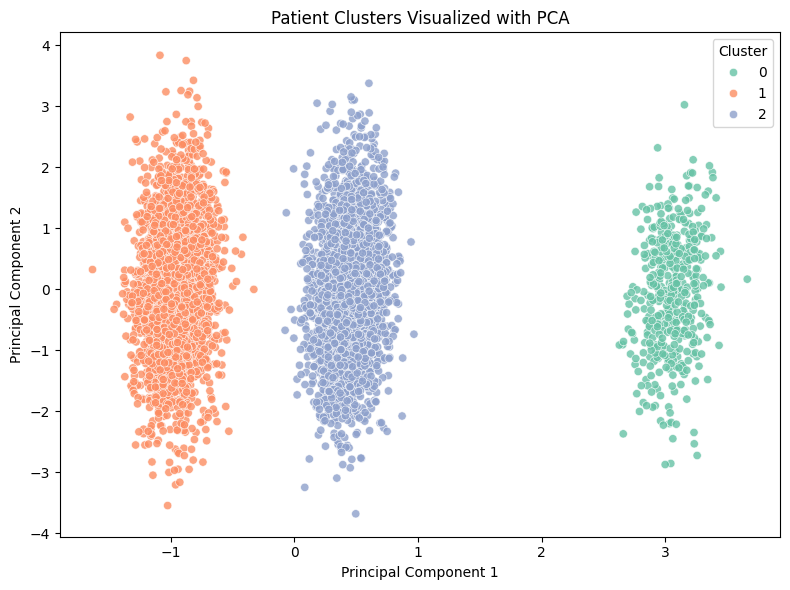

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster", palette="Set2", alpha=0.8)
plt.title("Patient Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

**Code pattern to learn:**  
A common visualization workflow is:
1. prepare a plotting DataFrame,
2. map one column to x,
3. map one column to y,
4. color by a label column.

**General pattern:**
```python
sns.scatterplot(data=df_plot, x="x_col", y="y_col", hue="label_col")
plt.show()
```

This is one of the most reusable patterns for cluster visualization.

## Step 17: Write a simple interpretation

**What this code does:**  
This cell prints a compact interpretation helper:
- cluster sizes,
- top above-average features in each cluster using standardized values.

**Why this matters:**  
Clustering is only useful if we can explain what makes each group different.

In [ ]:
scaled_profile = df_scaled.groupby("Cluster").mean()

for cluster_id in sorted(scaled_profile.index):
    print(f"\nCluster {cluster_id}")
    print("-" * 30)
    top_features = scaled_profile.loc[cluster_id].drop("Cluster", errors="ignore").sort_values(ascending=False).head(5)
    print("Top above-average standardized features:")
    print(top_features)


Cluster 0
------------------------------
Top above-average standardized features:
smoking_status_Unknown    3.406617
plasma_glucose            0.065730
exercise_angina           0.052491
heart_disease             0.049885
age                       0.013282
Name: 0, dtype: float64

Cluster 1
------------------------------
Top above-average standardized features:
smoking_status_Smoker    1.074069
skin_thickness           0.019398
chest_pain_type          0.011643
hypertension             0.010255
blood_pressure           0.008151
Name: 1, dtype: float64

Cluster 2
------------------------------
Top above-average standardized features:
bmi               0.019190
max_heart_rate    0.011867
cholesterol       0.009465
gender            0.003359
insulin           0.003182
Name: 2, dtype: float64


**Code pattern to learn:**  
A useful interpretation pattern is:
1. summarize by group,
2. sort feature values,
3. inspect the top ones.

**General pattern:**
```python
summary = df.groupby("Group").mean()
summary.loc[group_id].sort_values(ascending=False).head()
```

This helps turn model output into human-readable insights.

# Final takeaway

You have now completed a full beginner-friendly clustering workflow:

1. loaded the dataset,
2. explored the structure,
3. handled missing values,
4. encoded categorical variables,
5. standardized the features,
6. applied K-means clustering,
7. profiled the clusters,
8. visualized them with PCA.

The most important lesson is not the exact code itself.  
The important lesson is the **pattern**:

**load → inspect → clean → encode → scale → cluster → summarize → visualize → interpret**